In [260]:
import numpy as np
import pandas as pd

def create_sequences(df, seq_len):
    num_entries = len(df)
    max_seq_start = num_entries - seq_len
    
    input_sequence_starts = np.arange(0, max_seq_start, 1)
    input_sequences = np.array([df.iloc[np.arange(start, start+seq_len, 1)] for start in input_sequence_starts])
    targets = np.array(df.iloc[input_sequence_starts + seq_len,0])

    return input_sequences, targets

inputs, targets = create_sequences(pd.DataFrame([(i,i) for i in range(1, 101)]), 5)

print(inputs[:5])
print(targets[:5])



[[[1 1]
  [2 2]
  [3 3]
  [4 4]
  [5 5]]

 [[2 2]
  [3 3]
  [4 4]
  [5 5]
  [6 6]]

 [[3 3]
  [4 4]
  [5 5]
  [6 6]
  [7 7]]

 [[4 4]
  [5 5]
  [6 6]
  [7 7]
  [8 8]]

 [[5 5]
  [6 6]
  [7 7]
  [8 8]
  [9 9]]]
[ 6  7  8  9 10]


In [261]:
from torch.utils.data import DataLoader


train_data = pd.read_csv('electricity_consumption/electricity_train.csv')

train_data["timestamp"] = pd.to_datetime(train_data["timestamp"])

# train_data["year"]   = train_data["timestamp"].dt.year
# train_data["month"]  = train_data["timestamp"].dt.month
# train_data["day"]    = train_data["timestamp"].dt.day
# train_data["hour"]   = train_data["timestamp"].dt.hour
# train_data["minute"] = train_data["timestamp"].dt.minute

train_data = train_data.drop(columns=["timestamp"])

print(train_data.iloc[0])

consumption   -0.704319
Name: 0, dtype: float64


In [262]:
X_train, y_train = create_sequences(train_data, 96)
print(X_train.shape, y_train.shape)
print(X_train[0,-1])
print(y_train[0])

(105119, 96, 1) (105119,)
[-0.70431852]
-0.7043185184993116


In [263]:
print(X_train[:10,-1])
print(y_train[:10])

[[-0.70431852]
 [-0.70431852]
 [-0.70431852]
 [-0.65364675]
 [-0.65364675]
 [-0.67898263]
 [-0.67898263]
 [-0.70431852]
 [-0.70431852]
 [-0.67898263]]
[-0.70431852 -0.70431852 -0.65364675 -0.65364675 -0.67898263 -0.67898263
 -0.70431852 -0.70431852 -0.67898263 -0.65364675]


In [264]:
from torch.utils.data import TensorDataset
import torch

dataset_train = TensorDataset(
    torch.from_numpy(X_train).float(),
    torch.from_numpy(y_train).float(),
)

print(len(dataset_train))

105119


In [265]:
import torch.nn as nn


class Net(nn.Module):

    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=1,  # Number of features in the input at each time step
            hidden_size=32,  # Size of the hidden state (memory vector)
            num_layers=2,  # Two stacked RNN layers
            batch_first=
            True  # When `True` the input and output tensors are provided as (batch, seq, feature) instead of (seq, batch, feature)
        )
        self.fc = nn.Linear(32, 1)
        self.apply(self._init_weights)

    def forward(self, x):
        out, _ = self.rnn(x)

        out = self.fc(out[:, -1, :])

        out = out.reshape(-1,)

        return out

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
            nn.init.zeros_(m.bias)

        elif isinstance(m, (nn.RNN, nn.LSTM, nn.GRU)):
            for name, param in m.named_parameters():
                if "weight_ih" in name:
                    nn.init.xavier_uniform_(param)
                elif "weight_hh" in name:
                    nn.init.orthogonal_(param)
                elif "bias" in name:
                    nn.init.zeros_(param)


In [266]:
import torch.nn as nn
import torch.nn.functional as F
import tqdm
import torch
import numpy as np
import matplotlib.pyplot as plt


def train_model(dataloader_train,
                dataloader_val,
                optimizer,
                net,
                num_epochs,
                create_plot=False):

    criterion = nn.MSELoss()
    loss_history = []

    for epoch in range(num_epochs):
        train_loss = 0
        val_loss = 0

        for features, labels in tqdm.tqdm(dataloader_train):
            optimizer.zero_grad()  # clear the gradients
            outputs = net(features)  # forward pass

            loss = criterion(outputs, labels)

            loss.backward()  # compute the gradients
            optimizer.step()  # tweak weights
            train_loss += loss.item()
            if num_epochs <= 5:
                loss_history.append((loss.item(), 0))

        train_loss /= len(dataloader_train)

        # with torch.no_grad():
        #     for features, labels in dataloader_val:
        #         outputs = net(features)
        #         loss = criterion(outputs, labels)
        #         val_loss += loss.item()

        # val_loss /= len(dataloader_val)

        # print(f"Average train and validation loss: {(train_loss, val_loss)}")

        if num_epochs <= 5:
            # loss_history.append((train_loss, val_loss))
            loss_history.append((train_loss, 0))

    if create_plot:
        losses = np.array(loss_history)

        plt.plot(np.arange(losses.shape[0]), losses[:, 0], label="Train Loss")
        plt.plot(np.arange(losses.shape[0]),
                 losses[:, 1],
                 label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss (MSE)")
        plt.ylim(0, np.max(loss_history) * 1.05)
        plt.show()
    return loss_history

In [267]:
from sklearn.model_selection import train_test_split
from torch.utils import data

#Stratified split:

labels = [sample[1] for sample in dataset_train]
indices = np.arange(len(dataset_train))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42
)

train_dataset = data.Subset(dataset_train, train_idx)
val_dataset = data.Subset(dataset_train, val_idx)


100%|██████████| 657/657 [00:19<00:00, 34.10it/s]


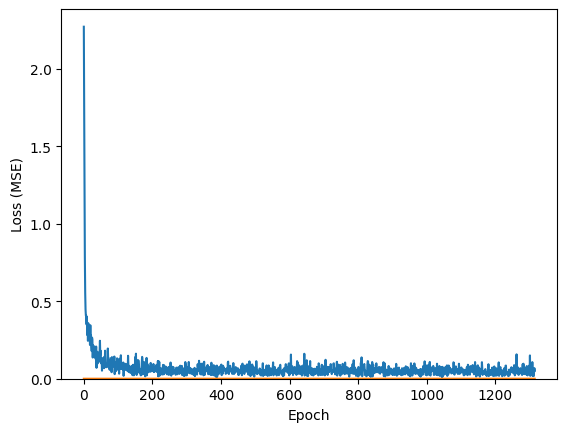

(0.05114996246993542, 0)


In [268]:
import torch.optim as optim

batch_size = 128
train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
net = Net()
learning_rate = 0.001
optimizer = optim.AdamW(net.parameters(), lr = learning_rate)

loss_history = train_model(train_loader, val_loader, optimizer, net, 2, True)
print(loss_history[-1])

In [269]:
test_data = pd.read_csv('electricity_consumption/electricity_train.csv')

test_data["timestamp"] = pd.to_datetime(test_data["timestamp"])

# test_data["year"]   = test_data["timestamp"].dt.year
# test_data["month"]  = test_data["timestamp"].dt.month
# test_data["day"]    = test_data["timestamp"].dt.day
# test_data["hour"]   = test_data["timestamp"].dt.hour
# test_data["minute"] = test_data["timestamp"].dt.minute

test_data = test_data.drop(columns=["timestamp"])


X_test, y_test = create_sequences(test_data, 96)

dataset_test = TensorDataset(
    torch.from_numpy(X_test).float(),
    torch.from_numpy(y_test).float(),
)

test_loader = data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False)




In [270]:
print(X_test[2])
print(y_test[2])

[[-0.67898263]
 [-0.65364675]
 [-0.70431852]
 [-0.70431852]
 [-0.72990776]
 [-0.70431852]
 [-0.70431852]
 [-0.67898263]
 [-0.67898263]
 [-0.62831087]
 [-0.67898263]
 [-0.72990776]
 [-0.72990776]
 [-0.72990776]
 [-0.70431852]
 [-0.67898263]
 [-0.70431852]
 [-0.75524365]
 [-0.67898263]
 [-0.67898263]
 [-0.67898263]
 [-0.65364675]
 [-0.72990776]
 [-0.70431852]
 [-0.67898263]
 [-0.67898263]
 [-0.70431852]
 [-0.72990776]
 [-0.70431852]
 [-0.72990776]
 [-0.67898263]
 [-0.70431852]
 [-0.75524365]
 [-0.90725895]
 [-1.00885585]
 [-0.95793072]
 [-0.93259484]
 [-0.98326661]
 [-0.98326661]
 [-1.00885585]
 [-0.98326661]
 [-1.00885585]
 [-0.98326661]
 [-0.95793072]
 [-0.95793072]
 [-0.95793072]
 [-0.95793072]
 [-1.00885585]
 [-0.98326661]
 [-0.95793072]
 [-0.98326661]
 [-0.98326661]
 [-1.00885585]
 [-0.95793072]
 [-0.93259484]
 [-1.00885585]
 [-0.98326661]
 [-0.93259484]
 [-0.98326661]
 [-1.03419173]
 [-0.98326661]
 [-0.98326661]
 [-0.85658718]
 [-0.67898263]
 [-0.72990776]
 [-0.72990776]
 [-0.70431

In [271]:
net.eval()                 # switch to evaluation mode
all_preds = []
all_targets = []

with torch.no_grad():      # disable gradient tracking
    for x, y in test_loader:
        preds = net(x)

        all_preds.append(preds)
        all_targets.append(y)

# concatenate batches
all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)


In [272]:
print(all_preds.shape)
print(all_targets.shape)

torch.Size([105119])
torch.Size([105119])


In [273]:
print(all_preds[:5])
print(all_targets[:5])

tensor([-0.6848, -0.6890, -0.6726, -0.6315, -0.6466])
tensor([-0.7043, -0.7043, -0.6536, -0.6536, -0.6790])


In [274]:
ss_res = torch.sum((all_targets - all_preds) ** 2)
ss_tot = torch.sum((all_targets - all_targets.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
print("R²:", r2.item())


R²: 0.9506585001945496
